In [1]:
!pip install qiskit qiskit-ibm-runtime qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 14.2 MB/s eta 0:00:00
  Created 

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import Aer
from IPython.display import display

print("All libraries imported successfully!")

All libraries imported successfully!


Experiment 1: X-Gate on Bloch Sphere and State Vector

Circuit for Experiment 1:


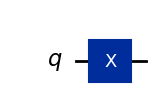


State Vector:


<IPython.core.display.Latex object>


Bloch Sphere:


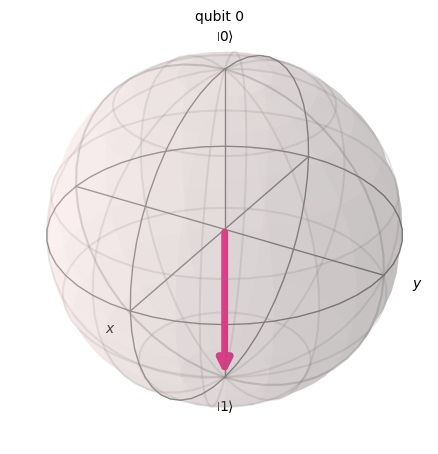

In [3]:
# 1. Create a quantum circuit with 1 qubit
qc1 = QuantumCircuit(1)

# Apply X-Gate
qc1.x(0)

# 2. Draw the Circuit
print("Circuit for Experiment 1:")
display(qc1.draw('mpl'))

# 4. Display the state vector
state1 = Statevector(qc1)
print("\nState Vector:")
display(state1.draw('latex'))

# 3. Show the qubit on Bloch Sphere
print("\nBloch Sphere:")
display(plot_bloch_multivector(state1))


Experiment 2: Single Qubit Gates with Initial State 1/√2(|0⟩ + |1⟩)


--- Applying Y Gate ---


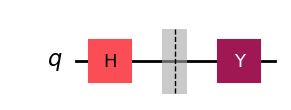

<IPython.core.display.Latex object>

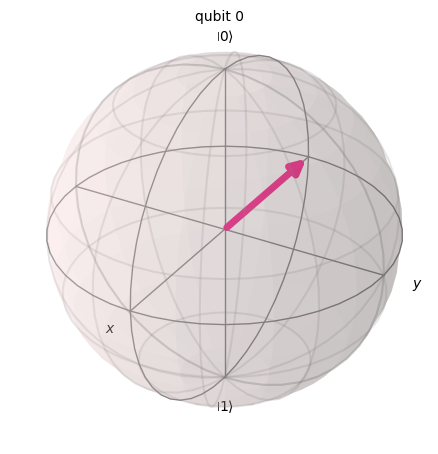


--- Applying Z Gate ---


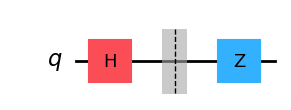

<IPython.core.display.Latex object>

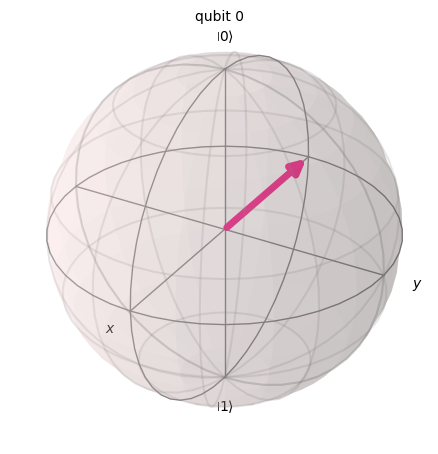


--- Applying Phase (pi/2) Gate ---


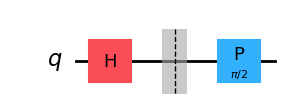

<IPython.core.display.Latex object>

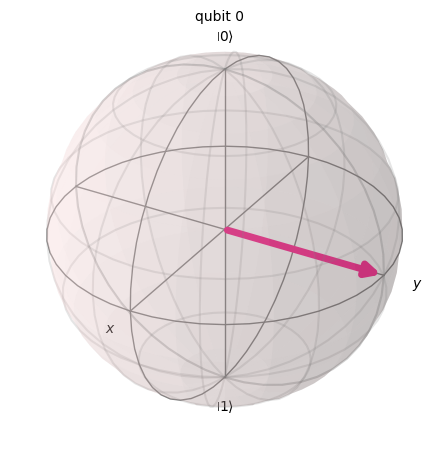


--- Applying S Gate ---


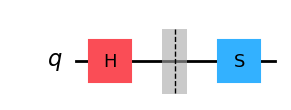

<IPython.core.display.Latex object>

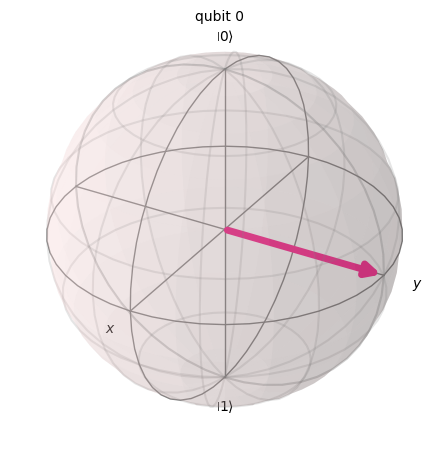


--- Applying S† (Sdg) Gate ---


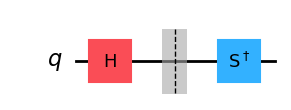

<IPython.core.display.Latex object>

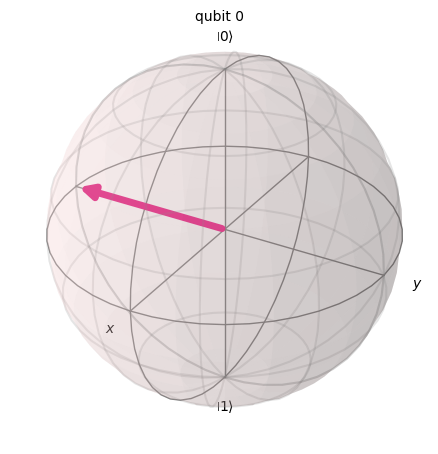


--- Applying T Gate ---


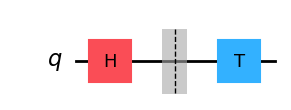

<IPython.core.display.Latex object>

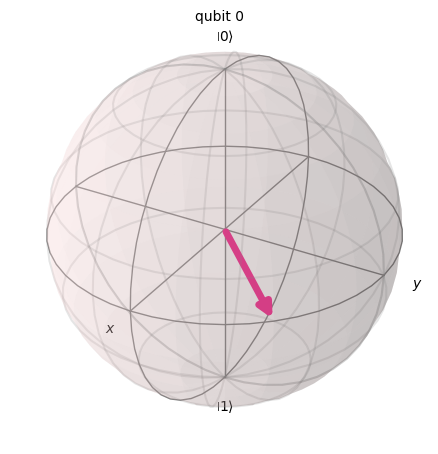


--- Applying T† (Tdg) Gate ---


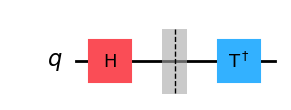

<IPython.core.display.Latex object>

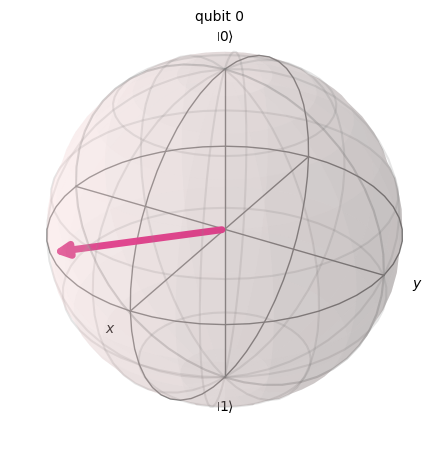

In [4]:
gates = {
    'Y': lambda qc: qc.y(0),
    'Z': lambda qc: qc.z(0),
    'Phase (pi/2)': lambda qc: qc.p(np.pi/2, 0),
    'S': lambda qc: qc.s(0),
    'S† (Sdg)': lambda qc: qc.sdg(0),
    'T': lambda qc: qc.t(0),
    'T† (Tdg)': lambda qc: qc.tdg(0)
}

for gate_name, apply_gate in gates.items():
    print(f"\n--- Applying {gate_name} Gate ---")
    qc2 = QuantumCircuit(1)

    # Create the initial state 1/sqrt(2)(|0> + |1>) using H gate
    qc2.h(0)
    qc2.barrier() # Barrier for visual separation

    # Apply the target gate
    apply_gate(qc2)

    # Draw circuit
    display(qc2.draw('mpl'))

    # State vector and Bloch sphere
    state2 = Statevector(qc2)
    display(state2.draw('latex'))
    display(plot_bloch_multivector(state2))


Experiment 3: Introduction to State Vector Simulator (Sampler)


--- Circuit (a) ---


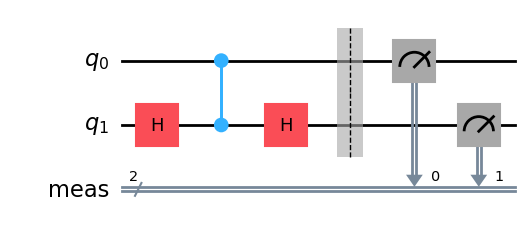

Measurement Results: {'00': 1024}


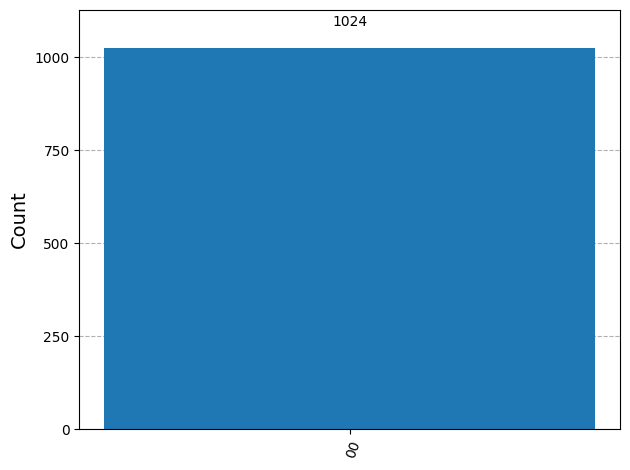


--- Circuit (b) ---


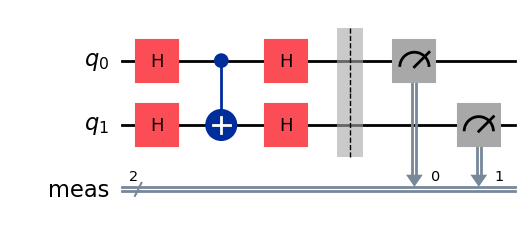

Measurement Results: {'00': 1024}


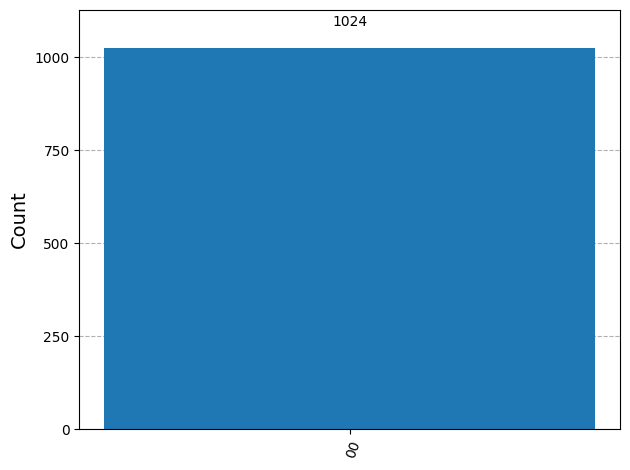


--- Circuit (c) ---


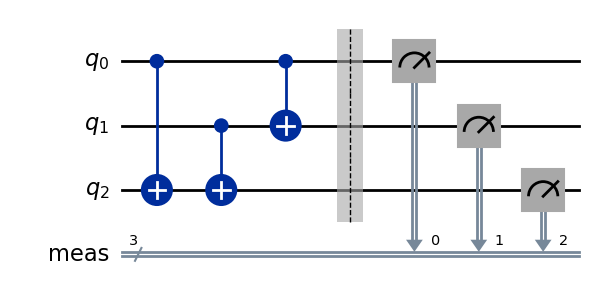

Measurement Results: {'000': 1024}


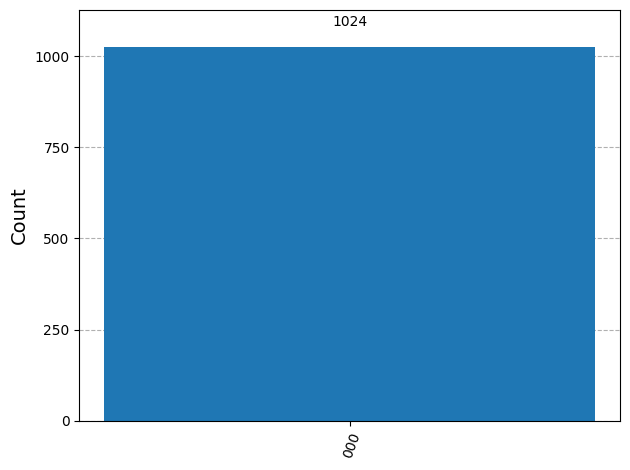


--- Circuit (d) ---


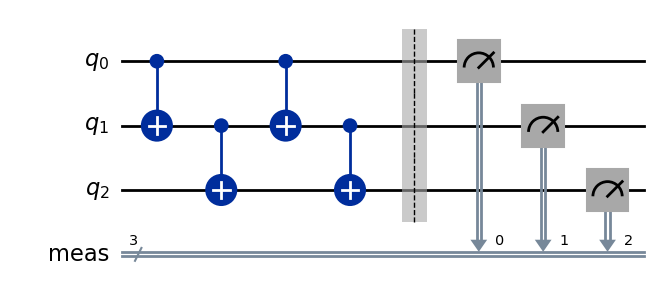

Measurement Results: {'000': 1024}


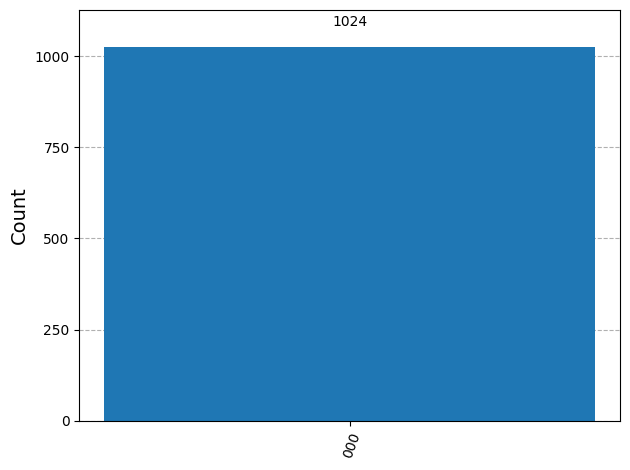

In [5]:
from qiskit.primitives import StatevectorSampler

# Define the circuits based on the assignment images
circuits = []

# (a) 2 Qubits: Control on q0, H-Z-H on q1
qc_a = QuantumCircuit(2)
qc_a.h(1)
qc_a.cz(0, 1) # Controlled-Z
qc_a.h(1)
qc_a.measure_all()
circuits.append(("Circuit (a)", qc_a))

# (b) 2 Qubits: H on both, CNOT(0->1), H on both
qc_b = QuantumCircuit(2)
qc_b.h(0)
qc_b.h(1)
qc_b.cx(0, 1) # CNOT control=0, target=1
qc_b.h(0)
qc_b.h(1)
qc_b.measure_all()
circuits.append(("Circuit (b)", qc_b))

# (c) 3 Qubits: CNOT(0->2), CNOT(1->2), CNOT(0->1)
qc_c = QuantumCircuit(3)
qc_c.cx(0, 2)
qc_c.cx(1, 2)
qc_c.cx(0, 1)
qc_c.measure_all()
circuits.append(("Circuit (c)", qc_c))

# (d) 3 Qubits: CNOT(0->1), CNOT(1->2), CNOT(0->1), CNOT(1->2)
qc_d = QuantumCircuit(3)
qc_d.cx(0, 1)
qc_d.cx(1, 2)
qc_d.cx(0, 1)
qc_d.cx(1, 2)
qc_d.measure_all()
circuits.append(("Circuit (d)", qc_d))

# Run them using the local Statevector Sampler primitive
sampler = StatevectorSampler()

for name, qc in circuits:
    print(f"\n--- {name} ---")
    display(qc.draw('mpl'))

    # Execute the circuit
    job = sampler.run([qc])
    result = job.result()

    # Extract counts (quasi-probabilities)
    pub_result = result[0]
    counts = pub_result.data.meas.get_counts()

    print("Measurement Results:", counts)
    display(plot_histogram(counts))


Experiment 4: Introduction to Qiskit Runtime (Real Hardware)

In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# --- AUTHENTICATION ---
MY_TOKEN = 'uatv0KCD_Ll5Y2LaMKAHmvE73HQL4NaKFBylvAztd6ix'

try:
    # Save account to disk (only needs to be done once)
    QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=MY_TOKEN, overwrite=True)
    service = QiskitRuntimeService()

    # Get the least busy backend
    # We use a simulator here for speed, change 'simulator=False' to use a real quantum computer.
    backend = service.least_busy(operational=True, simulator=True)
    print(f"Using backend: {backend.name}")

    # Re-define the circuits WITHOUT measurements (Estimator requires this)
    qc_a = QuantumCircuit(2); qc_a.h(1); qc_a.cz(0, 1); qc_a.h(1)
    qc_b = QuantumCircuit(2); qc_b.h(0); qc_b.h(1); qc_b.cx(0, 1); qc_b.h(0); qc_b.h(1)
    qc_c = QuantumCircuit(3); qc_c.cx(0, 2); qc_c.cx(1, 2); qc_c.cx(0, 1)
    qc_d = QuantumCircuit(3); qc_d.cx(0, 1); qc_d.cx(1, 2); qc_d.cx(0, 1); qc_d.cx(1, 2)

    # We will measure the 'Z' observable across all qubits for each circuit
    exp3_circuits = [
        ("Circuit (a)", qc_a, SparsePauliOp("ZZ")),
        ("Circuit (b)", qc_b, SparsePauliOp("ZZ")),
        ("Circuit (c)", qc_c, SparsePauliOp("ZZZ")),
        ("Circuit (d)", qc_d, SparsePauliOp("ZZZ"))
    ]

    # Transpile the circuits for the specific backend
    pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)
    estimator = EstimatorV2(backend)

    pub_list = []
    for name, qc, obs in exp3_circuits:
        isa_circuit = pm.run(qc)
        isa_observable = obs.apply_layout(isa_circuit.layout)
        pub_list.append((isa_circuit, isa_observable))

    # Run the job
    print("\nSubmitting job for all circuits...")
    job = estimator.run(pub_list)
    print(f"Job ID: {job.job_id()}")

    # Get results
    result = job.result()

    for i, (name, _, _) in enumerate(exp3_circuits):
        pub_result = result[i]
        print(f"{name} Expectation Value (Result): {pub_result.data.evs}")

except Exception as e:
    print("Error connecting to IBM Quantum. Did you paste your API token?")
    print(f"Details: {e}")


qiskit_runtime_service.__init__:WARNING:2026-04-24 03:05:45,143: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: First. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-24 03:05:45,925: Loading instance: First, plan: open


Error connecting to IBM Quantum. Did you paste your API token?
Details: 'No backend matches the criteria.'
